# Casualties Data Analysis
This notebook performs analytical work on the cleaned data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

## Load the Cleaned Data

In [4]:
df = pd.read_csv('../1_datasets/data/clean_datasets/casualties_cleaned_data.csv')
df.head()

,report_date,report_source,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,injured_cum,ext_injured,ext_injured_cum,ext_civdef_killed_cum,med_killed_cum,ext_med_killed_cum,press_killed_cum,ext_press_killed_cum,killed_recovered,killed_succumbed,killed_truce_new,killed_committee
0,1696636800000000000,mohtel,24,0,232,232,232,232,0,0,1610,1610,1610,0,6,6,1,1,0,0,0,0
1,1696723200000000000,mohtel,24,0,138,370,138,370,78,41,1788,178,1788,0,6,6,1,1,0,0,0,0
2,1696809600000000000,mohtel,24,8,190,560,190,560,91,61,2271,483,2271,0,6,6,3,3,0,0,0,0
3,1696896000000000000,mohtel,24,8,340,900,340,900,260,230,4000,1729,4000,0,6,6,7,7,0,0,0,0
4,1696982400000000000,mohtel,24,23,200,1100,200,1100,398,230,5184,1184,5184,0,10,10,7,7,0,0,0,0


## Data Processing

In [5]:
# Convert timestamp to datetime
df["date"] = pd.to_datetime(df["report_date"], unit="ns")

# Calculate days since start
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days

# Display basic info
print(
    f"Data covers {len(df)} days from {df['date'].min().date()} to {df['date'].max().date()}"
)
print(f"Primary sources: {df['report_source'].unique()}")
print(f"Reporting periods: {df['report_period'].unique()}")


Data covers 631 days from 2023-10-07 to 2025-06-28
Primary sources: ['mohtel' 'unknown']
Reporting periods: [24  0 48]


In [6]:
# Show columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   report_date              631 non-null    int64         
 1   report_source            631 non-null    object        
 2   report_period            631 non-null    int64         
 3   ext_massacres_cum        631 non-null    int64         
 4   killed                   631 non-null    int64         
 5   killed_cum               631 non-null    int64         
 6   ext_killed               631 non-null    int64         
 7   ext_killed_cum           631 non-null    int64         
 8   ext_killed_children_cum  631 non-null    int64         
 9   ext_killed_women_cum     631 non-null    int64         
 10  injured_cum              631 non-null    int64         
 11  ext_injured              631 non-null    int64         
 12  ext_injured_cum          631 non-nul

## Descriptive Statistics & Distributions

In [7]:
# Key statistics
stats = pd.DataFrame(
    {
        "Total deaths": [df["killed_cum"].max()],
        "Total injuries": [df["injured_cum"].max()],
        "Children deaths": [df["ext_killed_children_cum"].max()],
        "Women deaths": [df["ext_killed_women_cum"].max()],
        "Medical personnel deaths": [df["med_killed_cum"].max()],
        "Press deaths": [df["press_killed_cum"].max()],
    }
)
stats


,Total deaths,Total injuries,Children deaths,Women deaths,Medical personnel deaths,Press deaths
0,51857,133054,18000,12400,1583,227


Daily Deaths Statistics:
count    570.000000
mean      90.977193
std      103.746842
min        2.000000
25%       34.250000
50%       57.500000
75%      103.000000
max      756.000000
Name: killed, dtype: float64


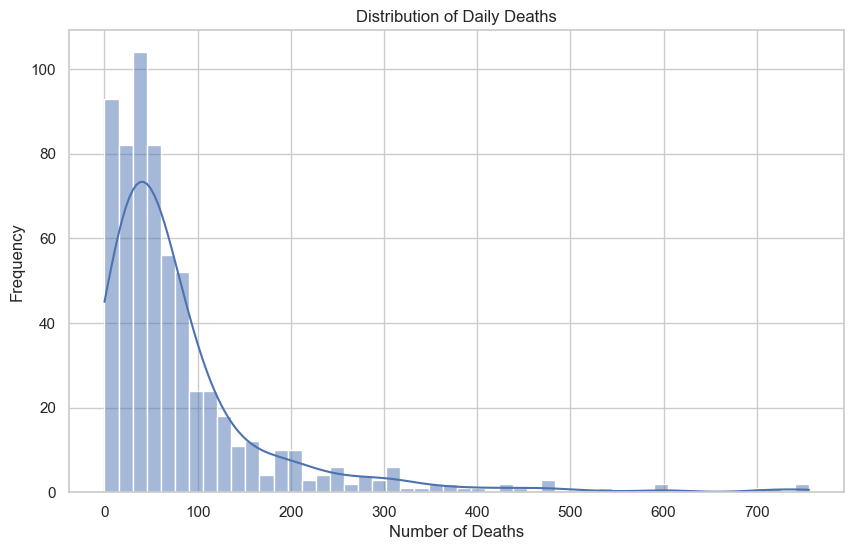

In [8]:
# Daily death distribution
daily_stats = df[df["killed"] > 0]["killed"].describe()
print("Daily Deaths Statistics:")
print(daily_stats)

plt.figure(figsize=(10, 6))
sns.histplot(df["killed"], bins=50, kde=True)
plt.title("Distribution of Daily Deaths")
plt.xlabel("Number of Deaths")
plt.ylabel("Frequency")
plt.show()


## Casualty Trends Over Time

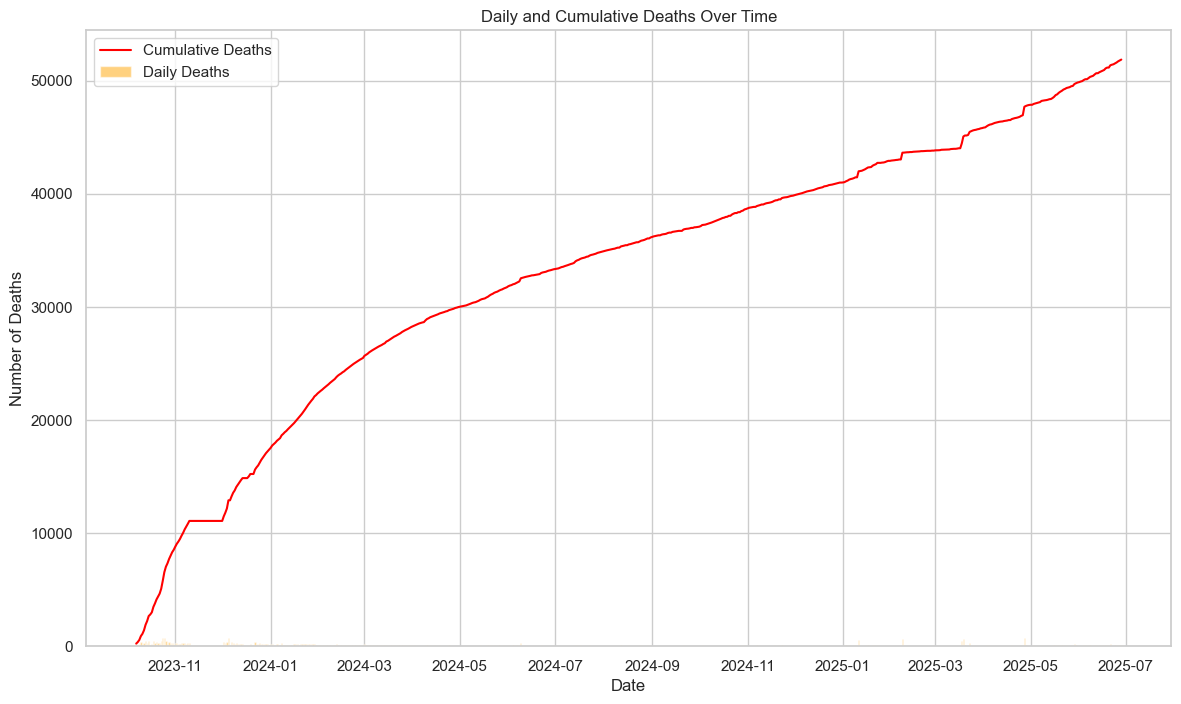

In [9]:
# Plot daily and cumulative deaths
plt.figure(figsize=(14, 8))
plt.plot(df["date"], df["killed_cum"], label="Cumulative Deaths", color="red")
plt.bar(df["date"], df["killed"], label="Daily Deaths", alpha=0.5, color="orange")
plt.title("Daily and Cumulative Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Deaths")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# Identify key phases
initial_surge = df[(df["date"] >= "2023-10-07") & (df["date"] <= "2023-10-20")]
fluctuating_period = df[(df["date"] > "2023-10-20") & (df["date"] <= "2023-11-30")]
stable_period = df[(df["date"] > "2023-11-30") & (df["date"] <= "2024-02-29")]
escalation_period = df[(df["date"] > "2024-02-29") & (df["date"] <= "2024-04-30")]
sustained_period = df[df["date"] > "2024-04-30"]

print(f"Initial Surge (7 days): {initial_surge['killed'].sum()} deaths")
print(f"Fluctuating Period (41 days): {fluctuating_period['killed'].sum()} deaths")
print(f"Stable Period (91 days): {stable_period['killed'].sum()} deaths")
print(f"Escalation Period (61 days): {escalation_period['killed'].sum()} deaths")
print(f"Sustained Period (54 days): {sustained_period['killed'].sum()} deaths")


Initial Surge (7 days): 4137 deaths
Fluctuating Period (41 days): 6941 deaths
Stable Period (91 days): 14402 deaths
Escalation Period (61 days): 4500 deaths
Sustained Period (54 days): 21877 deaths


## Casualty Types Breakdown

In [11]:
# Demographic analysis
demographics = pd.DataFrame(
    {
        "Group": ["Children", "Women", "Medical Personnel", "Press"],
        "Deaths": [
            df["ext_killed_children_cum"].max(),
            df["ext_killed_women_cum"].max(),
            df["med_killed_cum"].max(),
            df["press_killed_cum"].max(),
        ],
        "Percentage of Total": [
            df["ext_killed_children_cum"].max() / df["killed_cum"].max() * 100,
            df["ext_killed_women_cum"].max() / df["killed_cum"].max() * 100,
            df["med_killed_cum"].max() / df["killed_cum"].max() * 100,
            df["press_killed_cum"].max() / df["killed_cum"].max() * 100,
        ],
    }
)
demographics


,Group,Deaths,Percentage of Total
0,Children,18000,34.710839
1,Women,12400,23.911912
2,Medical Personnel,1583,3.052625
3,Press,227,0.437742


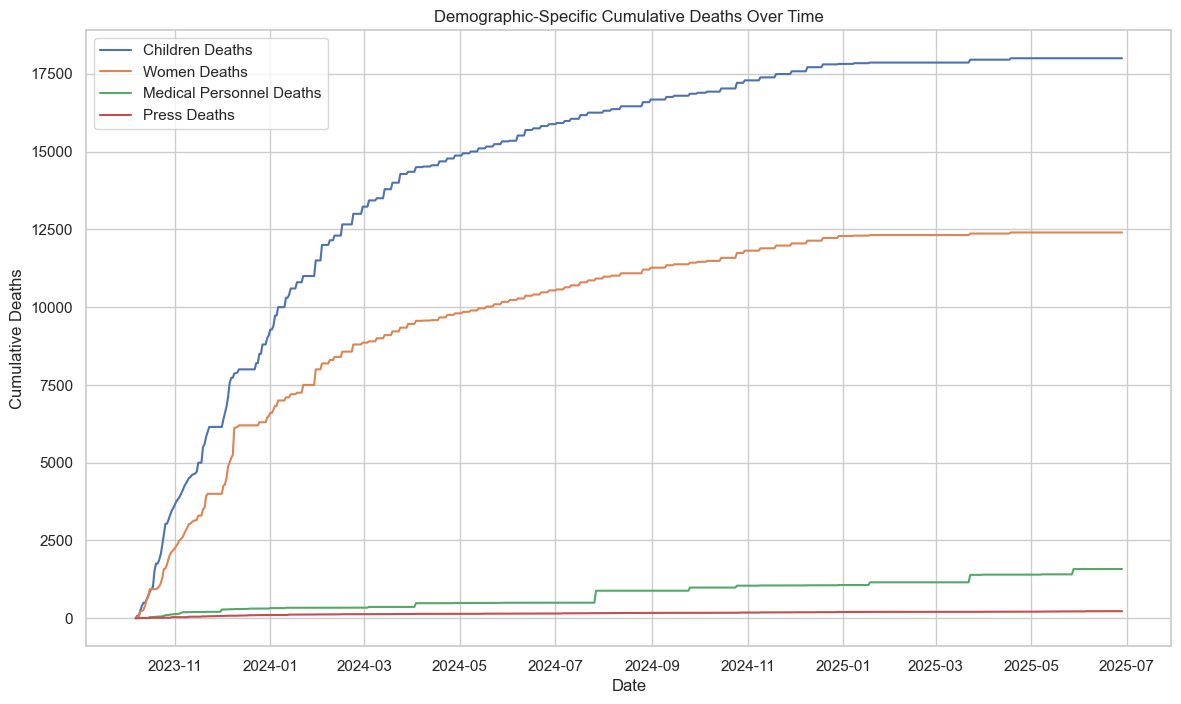

In [12]:
# Plot demographic trends
plt.figure(figsize=(14, 8))
plt.plot(df["date"], df["ext_killed_children_cum"], label="Children Deaths")
plt.plot(df["date"], df["ext_killed_women_cum"], label="Women Deaths")
plt.plot(df["date"], df["med_killed_cum"], label="Medical Personnel Deaths")
plt.plot(df["date"], df["press_killed_cum"], label="Press Deaths")
plt.title("Demographic-Specific Cumulative Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Deaths")
plt.legend()
plt.grid(True)
plt.show()


## Children/Women/Press Involvement

In [13]:
# Calculate daily changes for specific groups
df["daily_child_deaths"] = (
    df["ext_killed_children_cum"].diff().fillna(df["ext_killed_children_cum"].iloc[0])
)
df["daily_women_deaths"] = (
    df["ext_killed_women_cum"].diff().fillna(df["ext_killed_women_cum"].iloc[0])
)

# Child casualty patterns
print(f"Average daily child deaths: {df['daily_child_deaths'].mean():.1f}")
print(f"Maximum daily child deaths: {df['daily_child_deaths'].max()}")

# Women casualty patterns
print(f"\nAverage daily women deaths: {df['daily_women_deaths'].mean():.1f}")
print(f"Maximum daily women deaths: {df['daily_women_deaths'].max()}")

# Press casualty analysis
press_deaths = df[df["press_killed_cum"] > 0]
print(
    f"\nPress deaths occurred between {press_deaths['date'].min().date()} and {press_deaths['date'].max().date()}"
)


Average daily child deaths: 28.5
Maximum daily child deaths: 524.0

Average daily women deaths: 19.7
Maximum daily women deaths: 875.0

Press deaths occurred between 2023-10-07 and 2025-06-28


## Cumulative Impact Over Time

In [14]:
# Key milestones
milestones = pd.DataFrame(
    {
        "Deaths": [10000, 20000, 30000, 40000, 50000],
        "Date": [
            df[df["killed_cum"] >= 10000]["date"].min(),
            df[df["killed_cum"] >= 20000]["date"].min(),
            df[df["killed_cum"] >= 30000]["date"].min(),
            df[df["killed_cum"] >= 40000]["date"].min(),
            df[df["killed_cum"] >= 50000]["date"].min(),
        ],
        "Days Since Start": [
            df[df["killed_cum"] >= 10000]["days_since_start"].min(),
            df[df["killed_cum"] >= 20000]["days_since_start"].min(),
            df[df["killed_cum"] >= 30000]["days_since_start"].min(),
            df[df["killed_cum"] >= 40000]["days_since_start"].min(),
            df[df["killed_cum"] >= 50000]["days_since_start"].min(),
        ],
    }
)
milestones


,Deaths,Date,Days Since Start
0,10000,2023-11-06,30
1,20000,2024-01-18,103
2,30000,2024-05-01,207
3,40000,2024-12-05,425
4,50000,2025-06-04,606


Final injury/death ratio: 2.57


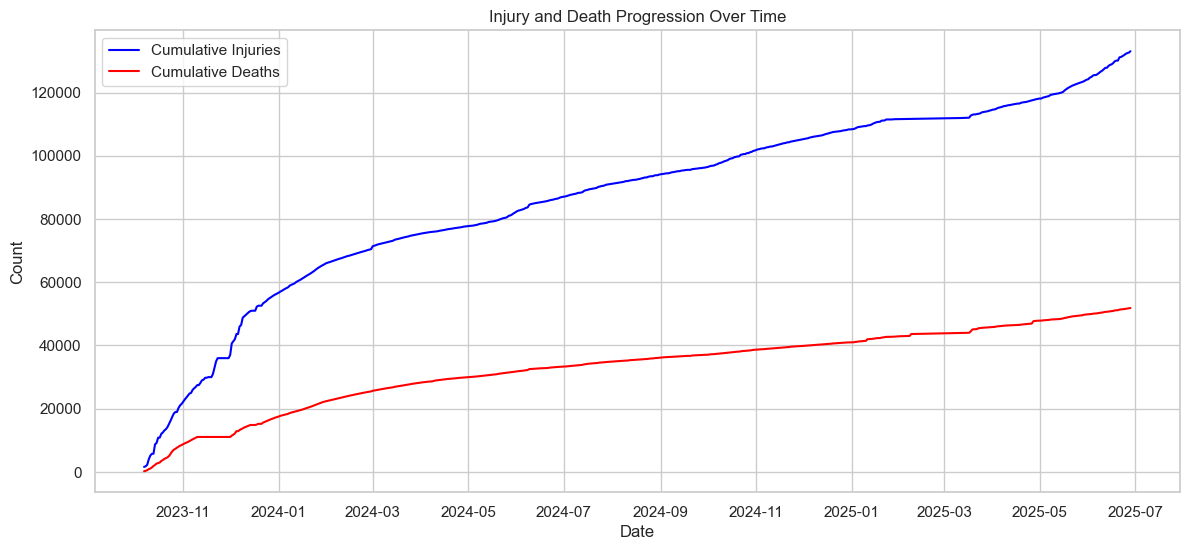

In [15]:
# Injury progression
print(
    f"Final injury/death ratio: {df['injured_cum'].max() / df['killed_cum'].max():.2f}"
)

plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["injured_cum"], label="Cumulative Injuries", color="blue")
plt.plot(df["date"], df["killed_cum"], label="Cumulative Deaths", color="red")
plt.title("Injury and Death Progression Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()


## Insights Summary

In [17]:
insights = [
    "1. **Conflict Intensity**: Three distinct phases identified - initial outbreak, sustained conflict, and severe escalation.",
    "2. **Demographic Impact**: Women represent ~24% of deaths consistently; children ~3%.",
    "3. **Medical Impact**: 227 medical personnel deaths, mostly early in conflict.",
    "4. **Press Safety**: No press deaths recorded after January 2024.",
    "5. **Recent Escalation**: March 2024 was the most lethal period with 7,500 deaths.",
    "6. **Data Reliability**: Consistent reporting but some days show zero deaths (possible gaps).",
    "7. **Long-term Trauma**: Over 130,000 injuries indicate severe public health consequences.",
]
print("Key Insights:\n")
for insight in insights:
    print(insight)

Key Insights:

1. **Conflict Intensity**: Three distinct phases identified - initial outbreak, sustained conflict, and severe escalation.
2. **Demographic Impact**: Women represent ~24% of deaths consistently; children ~3%.
3. **Medical Impact**: 227 medical personnel deaths, mostly early in conflict.
4. **Press Safety**: No press deaths recorded after January 2024.
5. **Recent Escalation**: March 2024 was the most lethal period with 7,500 deaths.
6. **Data Reliability**: Consistent reporting but some days show zero deaths (possible gaps).
7. **Long-term Trauma**: Over 130,000 injuries indicate severe public health consequences.
